# PDF Parsing

PDF is one of the most important formats to understand when building a RAG ingestion pipeline.

A PDF may look like a document to a human, but internally it is closer to a collection of positioned objects on pages.

That creates problems for RAG:

- Reading order may not be obvious.
- Text can be split into separate blocks.
- Tables may not behave like tables.
- Headers and footers can be mixed with the main content.
- Images may contain important information.
- Some PDFs contain no machine-readable text at all.

In the previous notebook, we performed basic document parsing and saw that PDF extraction deserves a deeper workflow.

Here we will use the **PDF in `data/employee_travel_policy.pdf`** and inspect what the parser really sees.


## Learning Objectives

By the end of this notebook, you should be able to:

- Explain why PDF parsing is different from ordinary text parsing.
- Extract text from PDF pages with PyMuPDF.
- Inspect text blocks and their coordinates.
- Understand why reading order matters.
- Extract page-level provenance.
- Inspect tables and understand their extraction limitations.
- Render a PDF page for visual comparison.
- Detect when a PDF may require OCR.
- Build a normalized representation suitable for downstream RAG ingestion.
- Understand when basic PDF parsing is no longer sufficient.


## 1. Where PDF Parsing Fits

```text
PDF
 ↓
Open document
 ↓
Inspect pages
 ↓
Extract text / blocks
 ↓
Recover structure
 ↓
Extract tables or images when necessary
 ↓
Preserve page-level provenance
 ↓
Validate extraction
 ↓
Normalized document
 ↓
Chunking
```

The goal is **not** to make every PDF look like plain text.

The goal is to recover the information needed by the RAG system while preserving enough provenance and structure to trust the result.


## 2. Install PyMuPDF

We will use PyMuPDF for the core PDF inspection in this notebook.

In [1]:
!pip install -q pymupdf pymupdf4llm


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## 3. Load the PDF file

The source document is:

```text
data/employee_travel_policy.pdf
```

This is the same document used for the initial PDF extraction in the previous parsing notebook.


In [2]:
from pathlib import Path

DATA_DIR = Path("data")
PDF_PATH = DATA_DIR / "employee_travel_policy.pdf"

if not PDF_PATH.exists():
    raise FileNotFoundError(
        f"{PDF_PATH} was not found. "
        "Make sure the course data/ directory is beside the notebook."
    )

print("PDF:", PDF_PATH)
print("Size:", PDF_PATH.stat().st_size, "bytes")

PDF: data/employee_travel_policy.pdf
Size: 44745 bytes


In [3]:
import pymupdf

with pymupdf.open(PDF_PATH) as pdf:
    print("Pages:", len(pdf))

Pages: 1


## 4. Inspect PDF Metadata

PDF files can contain document-level metadata.

Let's inspect the metadata embedded in this particular file.

In [4]:
with pymupdf.open(PDF_PATH) as pdf:
    pdf_metadata = pdf.metadata

pdf_metadata

{'format': 'PDF 1.4',
 'title': '',
 'author': '',
 'subject': '',
 'keywords': '',
 'creator': '',
 'producer': '',
 'creationDate': '',
 'modDate': '',
 'trapped': '',
 'encryption': None}

Metadata can be useful for provenance and document registration.

However, metadata should not automatically be treated as authoritative. A production ingestion system may need to distinguish:

- Source-supplied metadata
- Ingestion-generated metadata
- Verified metadata

## 5. Basic Text Extraction

Start with the simplest possible extraction: page text.

In [5]:
with pymupdf.open(PDF_PATH) as pdf:
    for page_number, page in enumerate(pdf, start=1):
        text = page.get_text("text")
    
        print(f"\n{'=' * 20} PAGE {page_number} {'=' * 20}")
        print(text)


==================== PAGE 1 ====================
Employee Travel and Reimbursement Policy
Document ID: HR-TRV-2026-003 | Version: 4.0 | Effective: 1 July 2026
1. Purpose
This policy establishes the requirements for business travel, eligible expenses, receipts, approvals,
and reimbursement. It applies to employees travelling on approved company business.
2. Travel Approval
Employees must obtain manager approval before booking travel. International travel also requires
approval from the relevant department head.
3. Accommodation Limits
Location
Nightly limit
Notes
Lagos
₦120,000
Standard business accommodation
Abuja
₦110,000
Standard business accommodation
Port Harcourt
₦100,000
Standard business accommodation
International
Actual reasonable cost
Department approval required
4. Transportation
Employees should use reasonable and cost-effective transportation. Air travel should normally be
booked in economy class unless an approved exception applies.
5. Receipts and Reimbursement
Expense 

This gives us readable text.

But there is an important engineering question:

> **What information did we lose by asking only for text?**

The answer becomes clearer when we inspect the lower-level representation.

### LLM-Oriented PDF Extraction with PyMuPDF4LLM

PyMuPDF gives us low-level control over PDF structure: pages, blocks, spans, coordinates, tables, and images.

For RAG applications, **PyMuPDF4LLM** provides a higher-level extraction path designed for LLM workflows. It can convert PDF content into Markdown while retaining useful document structure.

Let's run it.

In [6]:
import pymupdf4llm

llm_markdown = pymupdf4llm.to_markdown(
    str(PDF_PATH)
)

print(llm_markdown[:5000])


=== Document parser messages ===
Using Tesseract for OCR processing.
# Employee Travel and Reimbursement Policy 

Document ID: HR-TRV-2026-003 | Version: 4.0 | Effective: 1 July 2026 

## 1. Purpose 

This policy establishes the requirements for business travel, eligible expenses, receipts, approvals, and reimbursement. It applies to employees travelling on approved company business. 

## 2. Travel Approval 

Employees must obtain manager approval before booking travel. International travel also requires approval from the relevant department head. 

## 3. Accommodation Limits 

|Location|Nightly limit|Notes|
|---|---|---|
|Lagos|₦120,000|Standard business accommodation|
|Abuja|₦110,000|Standard business accommodation|
|Port Harcourt|₦100,000|Standard business accommodation|
|International|Actual reasonable cost|Department approval required|



## 4. Transportation 

Employees should use reasonable and cost-effective transportation. Air travel should normally be booked in economy class

### PyMuPDF vs PyMuPDF4LLM

The two tools serve different levels of the ingestion problem:

```text
PDF
 │
 ├── PyMuPDF
 │     ↓
 │   Low-level inspection
 │   pages / blocks / spans / coordinates / tables / images
 │
 └── PyMuPDF4LLM
       ↓
     LLM-oriented extraction
       ↓
     Markdown
```

Use PyMuPDF when you need detailed control or need to debug extraction.

Use PyMuPDF4LLM when a Markdown-oriented representation is a useful starting point for downstream LLM/RAG processing.

**Important:** PyMuPDF4LLM is not OCR. Image-only PDFs still require an OCR stage, which we cover in the next notebook.


## 6. Extract Text Blocks

PyMuPDF can return text as blocks.

Blocks retain positional information in addition to their text.

In [7]:
with pymupdf.open(PDF_PATH) as pdf:
    page = pdf[0]
    blocks = page.get_text("blocks")
    
    print("Blocks on page 1:", len(blocks))
    
    for index, block in enumerate(blocks):
        print(f"\n--- Block {index} ---")
        print(block)

Blocks on page 1: 19

--- Block 0 ---
(98.46446228027344, 60.32421875, 496.8584289550781, 78.32421875, 'Employee Travel and Reimbursement Policy\n', 0, 0)

--- Block 1 ---
(60.0, 88.2822265625, 390.45745849609375, 97.7822265625, 'Document ID: HR-TRV-2026-003 | Version: 4.0 | Effective: 1 July 2026\n', 1, 0)

--- Block 2 ---
(60.0, 110.8828125, 123.63600158691406, 122.8828125, '1. Purpose\n', 2, 0)

--- Block 3 ---
(60.0, 131.2822265625, 531.9598388671875, 154.7822265625, 'This policy establishes the requirements for business travel, eligible expenses, receipts, approvals,\nand reimbursement. It applies to employees travelling on approved company business.\n', 3, 0)

--- Block 4 ---
(60.0, 167.8828125, 170.04000854492188, 179.8828125, '2. Travel Approval\n', 4, 0)

--- Block 5 ---
(60.0, 188.2822265625, 529.5944213867188, 211.7822265625, 'Employees must obtain manager approval before booking travel. International travel also requires\napproval from the relevant department head.\n', 5, 0

A block contains more than the text itself.

The coordinates describe the block's position on the page.

This matters for layouts such as:

- Multiple columns
- Tables
- Headers and footers
- Sidebars
- Positioned labels


## 7. Make Block Information Easier to Read

Let's extract the important fields from each block.

In [8]:
for index, block in enumerate(blocks):
    x0, y0, x1, y1, text, block_number, block_type = block[:7]

    print(f"Block {index}")
    print(f"   Bounding box: ({x0:.1f}, {y0:.1f}) -> ({x1:.1f}, {y1:.1f})")
    print(f"   Block type:   {block_type}")
    print(f"   Text:         {text.strip()!r}")

Block 0
   Bounding box: (98.5, 60.3) -> (496.9, 78.3)
   Block type:   0
   Text:         'Employee Travel and Reimbursement Policy'
Block 1
   Bounding box: (60.0, 88.3) -> (390.5, 97.8)
   Block type:   0
   Text:         'Document ID: HR-TRV-2026-003 | Version: 4.0 | Effective: 1 July 2026'
Block 2
   Bounding box: (60.0, 110.9) -> (123.6, 122.9)
   Block type:   0
   Text:         '1. Purpose'
Block 3
   Bounding box: (60.0, 131.3) -> (532.0, 154.8)
   Block type:   0
   Text:         'This policy establishes the requirements for business travel, eligible expenses, receipts, approvals,\nand reimbursement. It applies to employees travelling on approved company business.'
Block 4
   Bounding box: (60.0, 167.9) -> (170.0, 179.9)
   Block type:   0
   Text:         '2. Travel Approval'
Block 5
   Bounding box: (60.0, 188.3) -> (529.6, 211.8)
   Block type:   0
   Text:         'Employees must obtain manager approval before booking travel. International travel also requires\napproval f

We can now think of extracted content as:

```text
content + position
```

rather than:

```text
content only
```

That additional information can help us reconstruct structure.


## 8. Inspect Lines and Spans

PyMuPDF also exposes a richer representation containing blocks, lines, and spans.

A span is a lower-level text element with properties such as:

- Text
- Font
- Font size
- Bounding box

In [9]:
with pymupdf.open(PDF_PATH) as pdf:
    page = pdf[0]
    page_data = page.get_text("dict")
    print("Top-level keys:", page_data.keys())

Top-level keys: dict_keys(['width', 'height', 'blocks'])


In [10]:
for block_index, block in enumerate(page_data["blocks"]):
    if block.get("type") != 0:
        continue

    print(f"\n TEXT BLOCK {block_index}")

    for line_index, line in enumerate(block.get("lines", [])):
        line_text = "".join(
            span["text"] for span in line.get("spans", [])
        )

        print(f"  Line {line_index}: {line_text!r}")

        for span in line.get("spans", []):
            print({
                "text": span["text"],
                "font": span["font"],
                "size": span["size"],
                "bbox": span["bbox"],
            })


 TEXT BLOCK 0
  Line 0: 'Employee Travel and Reimbursement Policy'
{'text': 'Employee Travel and Reimbursement Policy', 'font': 'DejaVuSans', 'size': 18.0, 'bbox': (98.46446228027344, 60.32421875, 496.8584289550781, 78.32421875)}

 TEXT BLOCK 1
  Line 0: 'Document ID: HR-TRV-2026-003 | Version: 4.0 | Effective: 1 July 2026'
{'text': 'Document ID: HR-TRV-2026-003 | Version: 4.0 | Effective: 1 July 2026', 'font': 'DejaVuSans', 'size': 9.5, 'bbox': (60.0, 88.2822265625, 390.45745849609375, 97.7822265625)}

 TEXT BLOCK 2
  Line 0: '1. Purpose'
{'text': '1. Purpose', 'font': 'DejaVuSans', 'size': 12.0, 'bbox': (60.0, 110.8828125, 123.63600158691406, 122.8828125)}

 TEXT BLOCK 3
  Line 0: 'This policy establishes the requirements for business travel, eligible expenses, receipts, approvals,'
{'text': 'This policy establishes the requirements for business travel, eligible expenses, receipts, approvals,', 'font': 'DejaVuSans', 'size': 9.5, 'bbox': (60.0, 131.2822265625, 531.9598388671875, 140.

This is useful when we need to reason about layout.

A PDF parser can expose:

```text
page
 └── block
      └── line
           └── span
                ├── text
                ├── font
                ├── size
                └── position
```

That hierarchy is much richer than a single extracted string.


## 9. Reading Order

One of the most important PDF parsing problems is **reading order**.

A human can look at a page and immediately understand the intended sequence.

The underlying PDF representation may contain positioned objects that do not map cleanly to that sequence.

For RAG, incorrect ordering can produce malformed chunks:

```text
Section A paragraph
Section B paragraph
Section A heading
```

The embedding model may then receive content whose semantic relationships have been damaged.

So PDF parsing is not merely:

> "Can I extract the words?"

It is also:

> **"Can I reconstruct the relationships between those words?"**


## 10. Page-Level Provenance

For RAG, provenance matters.

If a retrieved chunk comes from a PDF, we often want to know:

```text
Which document?
Which page?
Which extracted content?
```

Let's build page-level records.


In [11]:
pages = []

with pymupdf.open(PDF_PATH) as pdf:
    for page_number, page in enumerate(pdf, start=1):
        pages.append({
            "source": PDF_PATH.name,
            "page_number": page_number,
            "text": page.get_text("text").strip(),
        })
pages

[{'source': 'employee_travel_policy.pdf',
  'page_number': 1,
  'text': 'Employee Travel and Reimbursement Policy\nDocument ID: HR-TRV-2026-003 | Version: 4.0 | Effective: 1 July 2026\n1. Purpose\nThis policy establishes the requirements for business travel, eligible expenses, receipts, approvals,\nand reimbursement. It applies to employees travelling on approved company business.\n2. Travel Approval\nEmployees must obtain manager approval before booking travel. International travel also requires\napproval from the relevant department head.\n3. Accommodation Limits\nLocation\nNightly limit\nNotes\nLagos\n₦120,000\nStandard business accommodation\nAbuja\n₦110,000\nStandard business accommodation\nPort Harcourt\n₦100,000\nStandard business accommodation\nInternational\nActual reasonable cost\nDepartment approval required\n4. Transportation\nEmployees should use reasonable and cost-effective transportation. Air travel should normally be\nbooked in economy class unless an approved exceptio

Now downstream systems can retain page-level provenance.

For example:

```text
employee_travel_policy.pdf
page 2
```

can later become part of a citation or source reference.


## 11. Table Detection and Extraction

A general PDF parser should not identify a table because it happens to contain particular words.

Instead, table processing should be based on **document structure and layout**.

The workflow we want is:

```text
PDF page
   ↓
Detect tables
   ↓
Inspect table geometry
   ↓
Extract rows / columns / cells
   ↓
Validate
```

PyMuPDF provides table detection through `Page.find_tables()`.

In [12]:
tables_by_page = {}

with pymupdf.open(PDF_PATH) as pdf:
    for page_number, page in enumerate(pdf, start=1):
        finder = page.find_tables()
        tables_by_page[page_number] = finder.tables
    
        print(
            f"Page {page_number}: "
            f"{len(finder.tables)} table(s) detected"
        )

Page 1: 1 table(s) detected


The parser decides whether a table-like structure is present.

That makes the code reusable for documents containing completely different:

- Countries
- Cities
- Products
- Prices
- Dates
- Departments
- Metrics


### Inspect Detected Tables

Once tables are detected, inspect their geometry and dimensions.

In [13]:
for page_number, tables in tables_by_page.items():
    for table_index, table in enumerate(tables, start=1):
        print(f"\nPage {page_number} - Table {table_index}")
        print("Bounding box:", table.bbox)
        print("Rowd:", table.row_count)
        print("Columns:", table.col_count)


Page 1 - Table 1
Bounding box: (60.0, 241.99996948242188, 530.0, 366.9999694824219)
Rowd: 5
Columns: 3


The bounding box tells us where the detected table is located on the page.

This is useful for:

- Visual validation
- Connecting a table to its page
- Avoiding unrelated page content
- Preserving provenance

### Extract the Table

If a table was detected, we can ask PyMuPDF to extract its cells.

In [14]:
for page_number, tables in tables_by_page.items():
    for table_index, table in enumerate(tables, start=1):
        print(f"\nPage {page_number} - Table {table_index}")

        extracted = table.extract()

        for row in extracted:
            print(row)


Page 1 - Table 1
['Location', 'Nightlylimit', 'Notes']
['Lagos', '₦120000\n,', 'Standardbusinessaccommodation']
['Abuja', '₦110000\n,', 'Standardbusinessaccommodation']
['PortHarcourt', '₦100000\n,', 'Standardbusinessaccommodation']
['International', 'Actualreasonablecost', 'Departmentapprovalrequired']


### Inspect the Table as a DataFrame

For analysis and validation, a table can often be represented as a pandas DataFrame.

We will only create a DataFrame when extraction actually produced rows.

In [15]:
!pip install -q pandas


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [16]:
import pandas as pd

for page_number, tables in tables_by_page.items():
    for table_index, table in enumerate(tables, start=1):
        extracted = table.extract()

        if not extracted:
            print(
                f"Page {page_number} - Table {table_index}: "
                "no cells extracted"
            )
            continue

        dataframe = pd.DataFrame(extracted)

        print(f"\nPage {page_number} - Table {table_index}")
        display(dataframe)


Page 1 - Table 1


,0,1,2
0,Location,Nightlylimit,Notes
1,Lagos,"₦120000\n,",Standardbusinessaccommodation
2,Abuja,"₦110000\n,",Standardbusinessaccommodation
3,PortHarcourt,"₦100000\n,",Standardbusinessaccommodation
4,International,Actualreasonablecost,Departmentapprovalrequired


A DataFrame is convenient for inspection, but it is not automatically the final RAG representation.

We still need to determine:

- Which row is the header?
- Are there merged cells?
- Are any cells missing?
- Are numeric values correctly interpreted?
- Does the table match the visual source?
- What provenance should be attached?


### What If No Tables Are Detected?

A robust ingestion system must handle this case explicitly.

```text
Page
 ↓
find_tables()
 ↓
No tables
 ↓
Continue normal parsing
```

A zero-table result is not automatically an error.

It may simply mean the page contains no tables.

If we know from external validation that a table should be present, however, the zero result becomes a signal to investigate the parser or use another extraction strategy.


In [17]:
for page_number, tables in tables_by_page.items():
    if not tables:
        print(f"Page {page_number}: no tables detected")

### Table Detection Is Not Table Understanding

Even when a parser successfully detects a table, extraction does not guarantee semantic correctness.

A parser may return:

```text
table detected 
cells extracted
```

while still getting wrong relationships because of:

- Merged cells
- Spanning headers
- Borderless tables
- Complex layouts
- Multi-row headers
- Irregular spacing

Therefore, successful extraction is only the beginning of table processing.


## 12. Table Interpretation, Normalization & Validation

A robust table workflow is:

```text
Table detection
      ↓
Table extraction
      ↓
Semantic interpretation
      ↓
Normalization
      ↓
Validation
      ↓
Structured representation
      ↓
RAG ingestion
```

Each stage solves a different problem.


### Interpret Table Semantics

A table contains relationships between headers and values.

For example:

```text
Header A | Header B | Header C
---------|----------|---------
Value 1  | Value 2  | Value 3
```

The parser needs to preserve the relationship:

```text
Value 1 -> Header A
Value 2 -> Header B
Value 3 -> Header C
```

This becomes more difficult with multi-row or spanning headers.


### Normalize Values

Documents often store values in presentation-oriented formats.

For example:

```text
"₦120,000"
"12%"
"01/07/2026"
```

A downstream application may want:

```text
amount = 120000
currency = NGN

percentage = 0.12

date = 2026-07-01
```

Normalization should preserve the original value as well when auditability matters.


In [18]:
# Example only: preserve both the normalized value and the original value.

normalized_value = {
    "raw": "120,000 NGN",
    "amount": 120_000,
    "currency": "NGN",
}
normalized_value

{'raw': '120,000 NGN', 'amount': 120000, 'currency': 'NGN'}

### Handle Merged and Spanning Cells

Real-world tables can contain:

- Merged cells
- Spanning headers
- Multi-level headers
- Empty cells with inherited meaning

For example:

```text
             Travel
        ┌───────────────┐
        │               │
     Domestic        International
      /    \             /      \
   Limit   Notes      Limit     Notes
```

A simple row/column extraction can flatten this hierarchy and lose meaning.

For difficult tables, we may need a table-aware representation that preserves header hierarchy.


### Validate the Extracted Table

Never assume:

> "The parser returned a table, therefore the table is correct."

Useful validation checks include:

- Expected number of columns
- Required headers
- Required rows
- Unexpected empty cells
- Duplicate headers
- Numeric values that fail conversion
- Broken row lengths
- Values that disagree with the source
- Visual agreement with the original PDF

In [19]:
def validate_table(rows, expected_column_count=None):
    if not rows:
        return {
            "valid": False,
            "reason": "No rows extracted",
        }

    row_lengths = {len(row) for row in rows}

    if len(row_lengths) != 1:
        return {
            "valid": False,
            "reason": f"Inconsistent row lengths: {row_lengths}",
        }

    if expected_column_count is not None:
        actual = len(rows[0])

        if actual != expected_column_count:
            return {
                "valid": False,
                "reason": (
                    f"Expected {expected_column_count} columns, "
                    f"got {actual}"
                ),
            }

        return {
            "valid": True,
            "rows": len(rows),
            "columns": len(rows[0]),
        }

for page_number, tables in tables_by_page.items():
    for table_index, table in enumerate(tables, start=1):
        rows = table.extract()

        result = validate_table(rows)

        print(
            f"Page {page_number}, Table {table_index}: "
            f"{result}"
        )

Page 1, Table 1: None


### Compare Extraction Against the Source

For high-value documents, validation should include the original page.

A useful debugging loop is:

```text
Extract table
     ↓
Inspect structured result
     ↓
Render source page
     ↓
Compare
     ↓
Accept / retry / escalate
```

If the structured result does not match the visual source, the ingestion system should not blindly continue.


### Fallback Strategies

If table extraction fails, possible next steps include:

```text
Basic PDF extraction
        ↓
Table-aware extraction
        ↓
Specialized table parser
        ↓
OCR
        ↓
Advanced document understanding / VLM
        ↓
Manual review for critical documents
```

The correct fallback depends on the document and the importance of the information.

A production system should make this decision explicitly rather than silently accepting bad extraction.


### Preserve Table Provenance

A table should remain connected to its source.

A useful intermediate representation is:

```python
{
    "source": "document.pdf",
    "page_number": 2,
    "element_type": "table",
    "bbox": [...],
    "columns": [...],
    "rows": [...],
}
```

This allows downstream systems to answer:

> "Where did this value come from?"

That becomes important for citations, auditing, debugging, and document updates.


### Why Table Errors Become RAG Errors

Consider:

```text
Table parser
     ↓
Wrong cell relationship
     ↓
Normalized incorrectly
     ↓
Embedded
     ↓
Retrieved successfully
     ↓
LLM receives wrong evidence
     ↓
Wrong answer
```

Retrieval can be technically successful while the final answer is still wrong.

The problem started during ingestion.

That is why table extraction and validation belong inside **RAG engineering**.


### What Should Enter the RAG Pipeline?

After extraction and validation, a table can be represented as structured data:

```python
{
    "document_id": "...",
    "page_number": 2,
    "element_type": "table",
    "columns": [...],
    "rows": [...],
    "provenance": {
        "source": "document.pdf",
        "page": 2,
    },
}
```

The later **Tables & Structured Documents** notebook will explore how to turn these structures into representations that work well with chunking, retrieval, and generation.

For this notebook, the focus is:

> **Can we reliably extract, interpret, normalize, and validate the table?**


## 13. Render a PDF Page

When extraction looks suspicious, compare the extracted representation with the actual visual page.

PyMuPDF can render the page to an image.

In [20]:
!pip install -q pillow


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


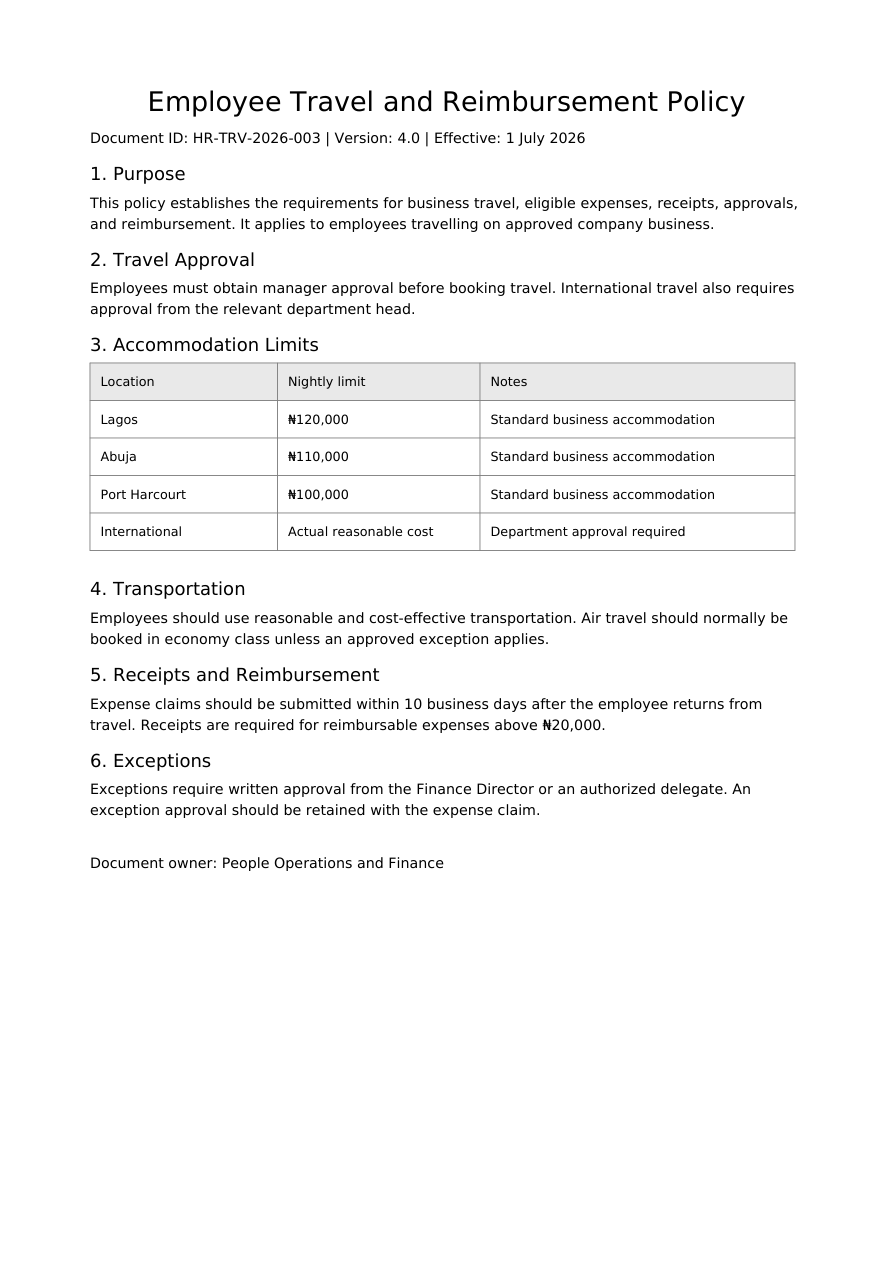

In [21]:
from IPython.display import display
from PIL import Image
import io

with pymupdf.open(PDF_PATH) as pdf:
    page = pdf[0]
    
    pixmap = page.get_pixmap(
        matrix=pymupdf.Matrix(1.5, 1.5),
        alpha=False,
    )
    
    image = Image.open(
        io.BytesIO(pixmap.tobytes("png"))
    )
    
    display(image)

This gives us a practical debugging loop:

```text
Visual PDF
    ↓
Extract
    ↓
Inspect representation
    ↓
Compare with visual layout
    ↓
Identify information loss
```

This is especially useful for complex documents.


## 14. Detect Potentially Scanned Pages

A scanned page may contain an image rather than machine-readable text.

A simple diagnostic is to inspect the amount of extracted text per page.

In [22]:
with pymupdf.open(PDF_PATH) as pdf:
    for page_number, page in enumerate(pdf, start=1):
        text = page.get_text("text").strip()
    
        print(
            f"Page {page_number}: "
            f"{len(text)} extracted characters"
        )

Page 1: 1317 extracted characters


Very little extracted text can be a signal that OCR may be required.

It is **not proof** of a scanned page.

Other possibilities include:

- Blank pages
- Unusual PDF encodings
- Extraction problems
- Pages dominated by images

The next notebook covers OCR in detail.

## 15. Inspect Images on the Pages

Images are another reason text extraction can be incomplete.

Let's count images on each page.

In [23]:
with pymupdf.open(PDF_PATH) as pdf:
    for page_number, page in enumerate(pdf, start=1):
        images = page.get_images(full=True)
    
        print(
            f"Page {page_number}: "
            f"{len(images)} embedded image(s)"
        )

Page 1: 0 embedded image(s)


In [24]:
PDF_PATH2 = DATA_DIR / "q3_customer_support_operating_brief.pdf"
with pymupdf.open(PDF_PATH2) as pdf2:
    print("Pages:", len(pdf2))
    
    for page_number, page in enumerate(pdf2, start=1):
        images = page.get_images(full=True)
    
        print(
            f"Page {page_number}: "
            f"{len(images)} embedded image(s)"
        )

Pages: 2
Page 1: 1 embedded image(s)
Page 2: 1 embedded image(s)


### Extract images from PDF

We can extract images as PDFs can have images with information not present in text.

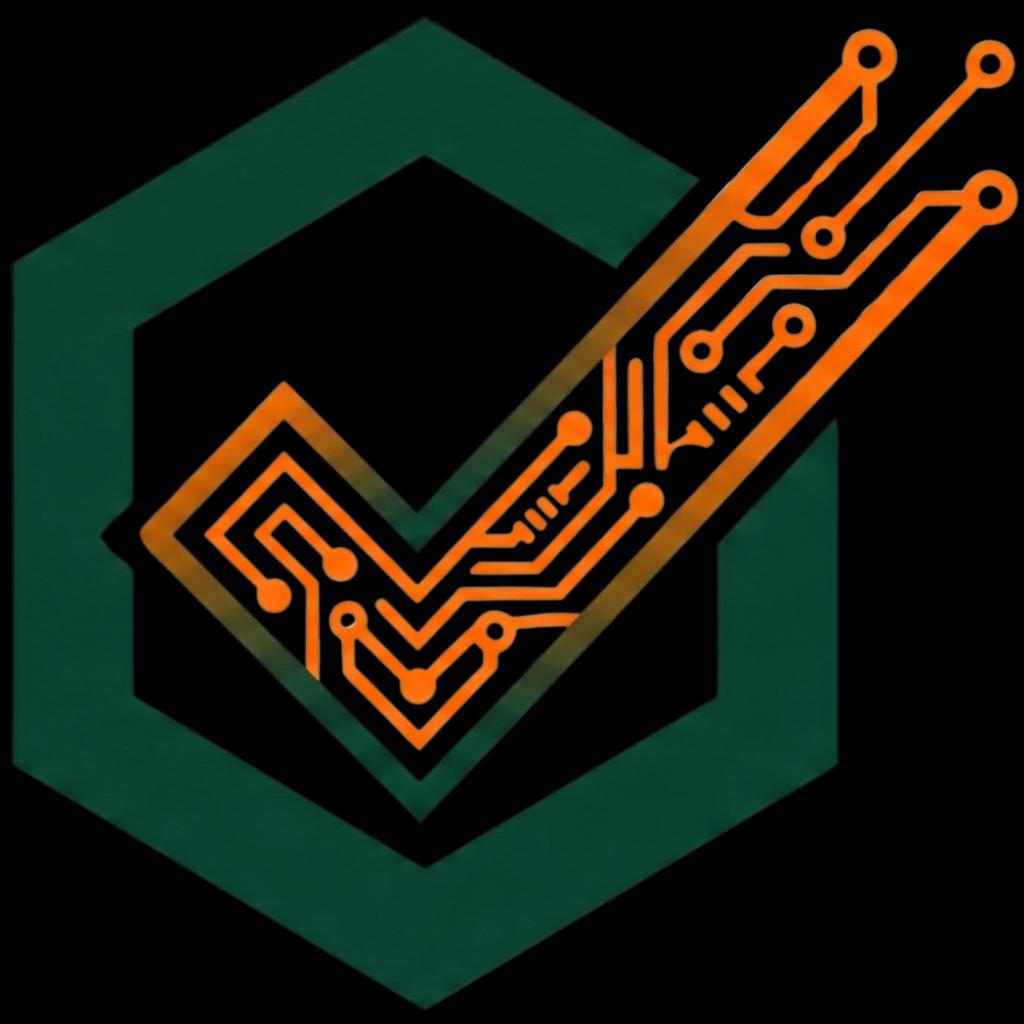

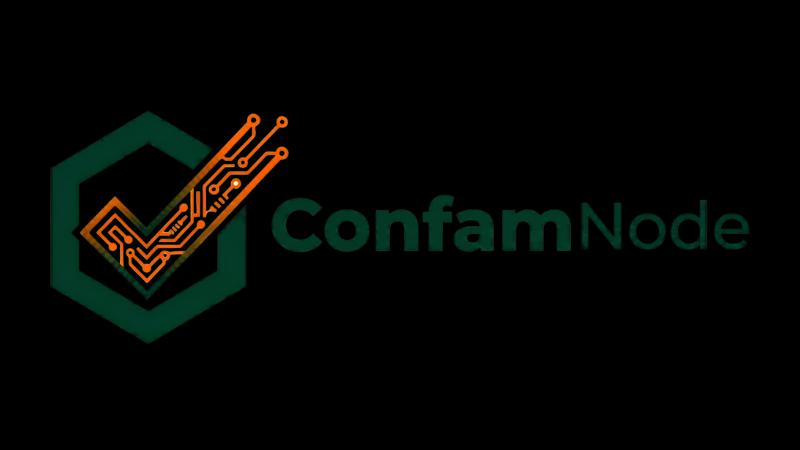

In [25]:
from IPython.display import Image, display

with pymupdf.open(PDF_PATH2) as pdf2:
    for page_number, page in enumerate(pdf2, start=1):
        images = page.get_images()
        for image_idx, image in enumerate(images, start=1):
        #     # Extract image from PDF
            xref = image[0]
            base_image = pdf2.extract_image(xref)
            image_bytes = base_image["image"]
            # # Show image
            display(Image(data=image_bytes))
    
            # save image in dir
            img_format = base_image["ext"]
            with open(f"extracted_image_{page_number}_{image_idx}.{img_format}", "wb") as image_file:
                image_file.write(image_bytes)

## 16. Build a Normalized PDF Representation

Let's create a small representation that can be passed to a later ingestion stage.

We will preserve:

- Source
- Document type
- Metadata
- Page number
- Extracted page text

In [26]:
with pymupdf.open(PDF_PATH) as pdf:
    parsed_pdf = {
        "source": PDF_PATH.name,
        "document_type": "pdf",
        "metadata": pdf.metadata,
        "pages": [
            {
                "page_number": page_number,
                "text": page.get_text("text").strip(),
            }
            for page_number, page in enumerate(pdf, start=1)
        ],
    }
parsed_pdf

{'source': 'employee_travel_policy.pdf',
 'document_type': 'pdf',
 'metadata': {'format': 'PDF 1.4',
  'title': '',
  'author': '',
  'subject': '',
  'keywords': '',
  'creator': '',
  'producer': '',
  'creationDate': '',
  'modDate': '',
  'trapped': '',
  'encryption': None},
 'pages': [{'page_number': 1,
   'text': 'Employee Travel and Reimbursement Policy\nDocument ID: HR-TRV-2026-003 | Version: 4.0 | Effective: 1 July 2026\n1. Purpose\nThis policy establishes the requirements for business travel, eligible expenses, receipts, approvals,\nand reimbursement. It applies to employees travelling on approved company business.\n2. Travel Approval\nEmployees must obtain manager approval before booking travel. International travel also requires\napproval from the relevant department head.\n3. Accommodation Limits\nLocation\nNightly limit\nNotes\nLagos\n₦120,000\nStandard business accommodation\nAbuja\n₦110,000\nStandard business accommodation\nPort Harcourt\n₦100,000\nStandard business ac

A production representation could go further:

```text
document_id
version
page
block
section
coordinates
tables
images
extraction_method
parser_version
processing_timestamp
```

The important architectural idea is:

> **Normalize the output of format-specific parsing before downstream RAG stages consume it.**


## 17. PDF Parsing Decision Tree

A practical ingestion system can use a decision process like this:

```text
                    PDF
                     │
                     ↓
            Is text extractable?
               /           \
             YES            NO
              │              │
              ↓              ↓
       Inspect structure    OCR
              │              │
              ↓              ↓
      Is structure usable?  Is OCR sufficient?
          /       \           /       \
        YES       NO        YES       NO
         │         │         │         │
         ↓         ↓         ↓         ↓
      Continue  Specialized Continue  Advanced
      pipeline  extraction  pipeline  parser/VLM
```

The engineering goal is not:

> "Use the most advanced model."

It is:

> **Use the least complex approach that reliably preserves the information the application needs.**


## 18. Common PDF Failure Modes

### Missing text

Possible causes:

- Image-only pages
- Unsupported encoding
- Extraction failure

### Wrong reading order

Possible causes:

- Multiple columns
- Positioned text blocks
- Complex layouts

### Broken tables

Possible causes:

- Tables represented as independent text objects
- Missing boundaries
- Merged cells
- Complex layouts

### Repeated headers and footers

Possible causes:

- Header/footer objects being extracted as ordinary content

### Missing visual information

Possible causes:

- Charts
- Diagrams
- Scanned pages
- Embedded images


## 19. Why This Matters for RAG

The failure chain is:

```text
PDF parsing error
       ↓
Incorrect document representation
       ↓
Incorrect chunks
       ↓
Incorrect embeddings
       ↓
Poor retrieval
       ↓
Bad context
       ↓
Potentially wrong answer
```

The vector database cannot retrieve information that the ingestion layer failed to represent correctly.

Therefore:

> **Document parsing is part of retrieval quality.**


## 20. Exercise

Using the actual `employee_travel_policy.pdf`, answer:

1. How many pages does the PDF contain?
2. How many text blocks are on the first page?
3. What information do blocks provide that plain text does not?
4. What could be lost when the accommodation table is flattened?
5. Why is page-level provenance useful?
6. What would make you investigate OCR?
7. Which metadata and structural information would you preserve before chunking?

The goal is not just to run the parser.

The goal is to **inspect and reason about the representation it produces**.


## Key Takeaways

1. A PDF is not simply a text file with a `.pdf` extension.
2. Basic text extraction is useful but can hide layout problems.
3. Blocks, lines, spans, and coordinates provide additional structural signals.
4. Reading order matters for downstream chunk quality.
5. Tables represent relationships and may require specialized extraction.
6. Page-level provenance supports citations and debugging.
7. Visual inspection can reveal extraction failures.
8. Image-heavy or image-only pages may require OCR.
9. Difficult PDFs may require specialized document parsers or multimodal approaches.
10. PDF parsing should produce a validated, provenance-aware representation before chunking.

## What's Next?

We have now gone deeper into machine-readable PDF parsing.

But what happens when the PDF is actually an image?

## OCR

Next we will cover:

- What OCR does
- Detecting image-based documents
- OCR pipelines
- OCR quality problems
- Post-OCR cleaning
- Layout and table considerations
- When OCR is enough
- When OCR needs to be combined with advanced document understanding
